In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from src.data.datasets.gdb13 import GDB13Resources
from src.data.filters.molecular import FilterQuickInvalidPosMol
from src.data.transforms import ToOneHotGraphAdapter

data_resources = GDB13Resources(
    random_splits={
        'train': None,
        'valid': 10000,
        'test': 10000
    },
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    include_pos=True,
    include_charges=True,
    pre_filter_raw=FilterQuickInvalidPosMol(),
    subset_size=169550,
    num_workers=10
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.data.datasets.qm9 import QM9Resources
from src.data.transforms import ToOneHotGraphAdapter

data_resources = QM9Resources(
    random_splits={
        'train': None,
        'valid': 10000,
        'test': 10000
    },
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    sanitize=False,
    kekulize=True,
    remove_hydrogens=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.data.datasets.zinc import ZincResources
from src.data.filters.molecular import FilterQuickInvalidPosMol
from src.data.transforms import ToOneHotGraphAdapter

data_resources = ZincResources(
    random_splits={
        'train': None,
        'valid': 10000,
        'test': 10000
    },
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    include_pos=True,
    include_charges=True,
    #pre_filter_raw=FilterQuickInvalidPosMol(),
    num_workers=2,
    hard_remove_hydrogens=False
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_resources.prepare_data()

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


In [4]:
ds_train = data_resources.get('dataset', 'train')
ds_val = data_resources.get('dataset', 'valid')
ds_test = data_resources.get('dataset', 'test')

In [5]:
from src.data.dataloader import DataLoader
dl = DataLoader(ds_test, batch_size=256, shuffle=False, num_workers=0)

In [6]:
batch = next(iter(dl))

In [750]:
from src.datatypes.dense import sparse_graph_to_dense_graph
import torch

dense_batch = sparse_graph_to_dense_graph(batch, handle_one_hot=True)
dense_batch.edge_dist = torch.cdist(dense_batch.node_pos, dense_batch.node_pos)
dense_batch = dense_batch.apply_mask()

num_cls_x = dense_batch.x.shape[-1]
num_cls_e = dense_batch.edge_adjmat.shape[-1]
num_cls_c = dense_batch.node_charges.shape[-1]

In [803]:
from src.models.d4.geometry import get_ignored_eigenvalues, compute_gramm_matrix
get_ignored_eigenvalues(dense_batch.edge_dist, 3, dense_batch.edge_mask)

tensor([[-1.9840e-06, -8.2973e-07, -2.4546e-07,  1.7644e-07,  8.6236e-07,
          1.4191e-06],
        [-1.5042e-06, -7.3929e-07, -1.5355e-07,  0.0000e+00,  3.6174e-08,
          2.9109e-07],
        [-1.9239e-06, -6.7596e-07, -1.9948e-08,  1.4524e-07,  5.1724e-07,
          8.6916e-07],
        ...,
        [-1.8803e-06, -7.1033e-07,  1.9377e-07,  4.4226e-07,  8.8702e-07,
          2.0202e-06],
        [-1.9811e-06, -7.8653e-07, -2.6248e-07,  1.0912e-07,  4.2110e-07,
          6.3683e-07],
        [-9.5950e-07, -2.9064e-07, -5.5178e-08,  3.9371e-07,  9.7828e-07,
          1.3382e-06]], dtype=torch.float64)

In [799]:
B = compute_gramm_matrix(dense_batch.edge_dist, dense_batch.edge_mask)
eigvals, eigvecs = torch.linalg.eigh(B.to(torch.float64))

In [804]:
eigvals

tensor([[-1.9840e-06, -8.2973e-07, -2.4546e-07,  ...,  6.3031e-01,
          9.4916e+00,  2.5894e+01],
        [-1.5042e-06, -7.3929e-07, -1.5355e-07,  ...,  1.4768e-06,
          7.8069e+00,  1.5630e+01],
        [-1.9239e-06, -6.7596e-07, -1.9948e-08,  ...,  1.9146e-02,
          1.6760e+01,  1.7369e+01],
        ...,
        [-1.8803e-06, -7.1033e-07,  1.9377e-07,  ...,  1.3759e+00,
          1.5627e+01,  1.7500e+01],
        [-1.9811e-06, -7.8653e-07, -2.6248e-07,  ...,  3.3220e+00,
          6.2034e+00,  1.9707e+01],
        [-9.5950e-07, -2.9064e-07, -5.5178e-08,  ...,  6.7166e-01,
          8.4162e+00,  3.2780e+01]], dtype=torch.float64)

In [8]:
config = {
    'x': {
        'process': {'name': 'discrete_marginal'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    },
    'edge_adjmat': {
        'process': {'name': 'discrete_marginal'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    },
    'edge_dist': {
        'process': {'name': 'vp_gaussian'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    },
    'node_charges': {
        'process': {'name': 'discrete_marginal'},
        'schedule': {'name': 'cosine', 'params': {'max_time': 500}}
    }
}

process_kwargs = {
    'x': {'num_cls': num_cls_x},
    'edge_adjmat': {'num_cls': num_cls_e},
    'node_charges': {'num_cls': num_cls_c}
}

# create omega config
from omegaconf import OmegaConf
config = OmegaConf.create(config)

In [9]:
from src.noise.core import noise_process_from_config, dict_of_noise_processes_from_config

processes = dict_of_noise_processes_from_config(config, process_kwargs=process_kwargs)

In [635]:
from src.noise.graph_diffusion import GraphDiffusionProcess

diffusion = GraphDiffusionProcess(
    diffusion_procs_per_data=processes,
    undirected=True
)

In [636]:
from src.noise.multimodal_diffusion import ChainedNoiseProcess

noise_processes_before = {k: processes[k] for k in ['x', 'edge_adjmat', 'node_charges']}
noise_processes_after = {k: processes[k] for k in ['edge_dist']}

def combine_stationary(x_before, x_after, *args, **kwargs):
    x_before.edge_dist = x_after.edge_dist
    return x_before

def chain_sample_posterior(datapoint, *args, **kwargs):
    print('Passing through chain_sample_posterior')
    return datapoint


diffusion_chain = ChainedNoiseProcess(
    noise_process_before = GraphDiffusionProcess(noise_processes_before, undirected=True),
    noise_process_after = GraphDiffusionProcess(noise_processes_after, undirected=True),
    combine_stationary = combine_stationary,
    chain_sample_posterior = chain_sample_posterior
)

In [637]:
import torch
time = torch.randint(1, 500, (dense_batch.num_graphs,))

noisy_batch = diffusion.sample_from_original(dense_batch, time)
noisy_batch_chain = diffusion_chain.sample_from_original(dense_batch, time)

In [638]:
print(noisy_batch_chain)
print((dense_batch.x[0] - noisy_batch.x[0])[:4])
print((dense_batch.x[0] - noisy_batch_chain.x[0])[:4])
print((dense_batch.edge_dist[0] - noisy_batch.edge_dist[0])[:4, :4])
print((dense_batch.edge_dist[0] - noisy_batch_chain.edge_dist[0])[:4, :4])

DenseGraph(node_mask=[256, 9], x=[256, 9, 5], node_charges=[256, 9, 3], node_pos=[256, 9, 3], edge_adjmat=[256, 9, 9, 4], edge_mask=[256, 9, 9], edge_dist=[256, 9, 9], y=[256, 19], masked=True, collapsed=False)
tensor([[ 0.,  0.,  0.,  0.,  0.],
        [-1.,  0.,  0.,  1.,  0.],
        [ 0.,  0.,  0.,  1., -1.],
        [ 0., -1.,  0.,  1.,  0.]])
tensor([[-1.,  0.,  0.,  0.,  1.],
        [ 0.,  0.,  0.,  1., -1.],
        [ 0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  1., -1.]])
tensor([[ 0.0000,  1.4747,  3.3592,  2.4027],
        [ 1.4747,  0.0000, -0.7675,  3.2464],
        [ 3.3592, -0.7675,  0.0000,  2.6360],
        [ 2.4027,  3.2464,  2.6360,  0.0000]])
tensor([[0.0000, 2.0459, 1.9231, 2.3573],
        [2.0459, 0.0000, 1.9721, 2.1262],
        [1.9231, 1.9721, 0.0000, 1.1201],
        [2.3573, 2.1262, 1.1201, 0.0000]])


In [639]:
time[0] = 480

In [748]:
noisy_prev = diffusion.sample_posterior(dense_batch, noisy_batch, time)
noisy_prev_chain = diffusion_chain.sample_posterior(dense_batch, noisy_batch, time)
print(noisy_prev.edge_dist[0, :4, :4])
print(noisy_prev_chain.edge_dist[0, :4, :4])
print(noisy_prev_chain.edge_dist[0, :4, :4] - noisy_prev.edge_dist[0, :4, :4])
print(noisy_prev.x[0, :4])
print(noisy_prev_chain.x[0, :4])

Passing through chain_sample_posterior
tensor([[ 0.0000, -0.5537, -1.1401,  0.4104],
        [-0.5537,  0.0000,  2.0025, -0.3137],
        [-1.1401,  2.0025,  0.0000, -1.3218],
        [ 0.4104, -0.3137, -1.3218,  0.0000]])
tensor([[ 0.0000, -0.4858, -0.7842,  0.9168],
        [-0.4858,  0.0000,  1.8245, -0.1294],
        [-0.7842,  1.8245,  0.0000, -0.9626],
        [ 0.9168, -0.1294, -0.9626,  0.0000]])
tensor([[ 0.0000,  0.0679,  0.3559,  0.5063],
        [ 0.0679,  0.0000, -0.1780,  0.1843],
        [ 0.3559, -0.1780,  0.0000,  0.3592],
        [ 0.5063,  0.1843,  0.3592,  0.0000]])
tensor([[0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.]])
tensor([[0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.]])


In [641]:
diffusion_chain.sample_stationary(
    num_new_nodes=dense_batch.num_nodes_per_sample
)

DenseGraph(node_mask=[256, 9], x=[256, 9, 5], node_charges=[256, 9, 3], edge_adjmat=[256, 9, 9, 4], edge_mask=[256, 9, 9], edge_dist=[256, 9, 9], masked=False, collapsed=False)

In [31]:
ds_train[0]

SparseGraph(x=[9, 5], edge_index=[2, 22], edge_attr=[22, 3], node_pos=[9, 3], node_charges=[9, 3], y=[19], collapsed=[1])

In [10]:
ds_train[0].collapse('x', 'edge_attr', 'node_charges')

SparseGraph(x=[8], edge_index=[2, 20], edge_attr=[20], node_pos=[8, 3], node_charges=[8], y=[19], collapsed=True)

In [11]:
ds_train[0].to_onehot({'x': 4, 'edge_attr': 3, 'node_charges': 3})

SparseGraph(x=[8, 4], edge_index=[2, 20], edge_attr=[20, 3], node_pos=[8, 3], node_charges=[8, 3], y=[19], collapsed=[1])

In [37]:
ds_train.pre_transform

Compose([
  ToOneHotGraph(num_classes_node=4, num_classes_edge=3),
  ToOneHot(attr_name=node_charges, num_classes=3)
])

In [5]:
ds_train.edge_attr.argmax(dim=-1).unique(return_counts=True)

(tensor([0, 1, 2]), tensor([1804552,  208494,   61754]))

In [34]:
from src.evaluation.metrics.sampling import BondDistanceDistributionMetric

metric = BondDistanceDistributionMetric(ds_val)

In [35]:
metric.bond_types_probabilities

tensor([0.2376, 0.0275, 0.0084, 0.0000])

In [27]:
from src.evaluation.assignment.molecular import MolecularAssignment

assignment = MolecularAssignment(
    how_many_to_generate=10000,
    split='valid',
    data_resources=data_resources,
    metrics_3d=True,
    distribution_metrics=False
)

In [28]:
ds_train = data_resources.get('dataset', 'train')

In [29]:
def preproc(mol):
    mol = mol.clone()
    mol.x = mol.x.argmax(dim=-1)
    mol.edge_attr = mol.edge_attr.argmax(dim=-1)
    mol.node_charges = mol.node_charges.argmax(dim=-1)
    return mol

gen_mols = [preproc(ds_train[i]) for i in range(10000)]
assignment(gen_mols)

Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error in GetmolFrags
Valence error 

{'bond_distance': 0.00035858515184372663,
 'bond_distance_per_class': {'single': 0.0010683679720386863,
  'double': 0.003644123673439026,
  'triple': 0.0005928273312747478,
  'aromatic': 0.0},
 'edge_types_distribution': {'single': 0.2379184365272522,
  'double': 0.027448000386357307,
  'triple': 0.008150573819875717,
  'aromatic': 0.0},
 'molecular_validity': 0.995,
 'molecular_uniqueness': 1.0,
 'molecular_novelty': 0.1614070351758794}

In [40]:
import torch
print((torch.tensor([0.009, 0.011, 0.269, 0.0])*torch.tensor([0.2388, 0.0273, 0.0079, 0])).sum())
print((torch.tensor([0.017, 0.027, 0.066, 0.0])*torch.tensor([0.2388, 0.0273, 0.0079, 0])).sum())

tensor(0.0046)
tensor(0.0053)


In [ ]:

metric(gen_mols)

0.00277112


{'bond_distance': tensor(0.0128),
 'bond_distance_per_class': {'single': 0.0008507892489433289,
  'double': 0.3917207717895508,
  'triple': 0.008763935416936874,
  'aromatic': 0.0}}

In [32]:
# compute distance matrices for each training graph
from torch_geometric.utils import to_dense_adj
import torch
def compute_dists_types(data):
    types = to_dense_adj(data.edge_index, edge_attr=data.edge_attr.argmax(-1)+1, max_num_nodes=data.num_nodes)
    dists = torch.cdist(data.node_pos, data.node_pos, p=2)
    triang_matrix = torch.triu(torch.ones_like(dists), diagonal=1).bool()
    dists = dists[triang_matrix]
    types = types[0][triang_matrix]
    
    return (dists, types)

dists_types = [compute_dists_types(data) for data in ds_train]

In [33]:
dists_types[0]

(tensor([1.5287, 2.5846, 3.7879, 5.0536, 4.9912, 3.7333, 3.2036, 2.5634, 1.5520,
         2.4441, 3.6335, 3.7862, 2.4605, 2.4994, 1.5276, 1.5268, 2.6449, 2.5462,
         2.4244, 2.7280, 2.4174, 1.4682, 1.4258, 1.5010, 2.4787, 2.4046, 1.4317,
         2.5946, 3.8456, 3.6505, 2.5370, 3.3679, 3.7172, 1.4846, 1.4831, 1.4765]),
 tensor([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
         0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1]))

In [34]:
# prepare histograms of distances for each edge type
import numpy as np
import matplotlib.pyplot as plt
all_dists = np.concatenate([dts[0].numpy().flatten() for dts in dists_types])
all_types = np.concatenate([dts[1].numpy().flatten() for dts in dists_types])
num_edge_types = all_types.max()+1

In [35]:
torch.from_numpy(all_types).unique()

tensor([0, 1, 2, 3])

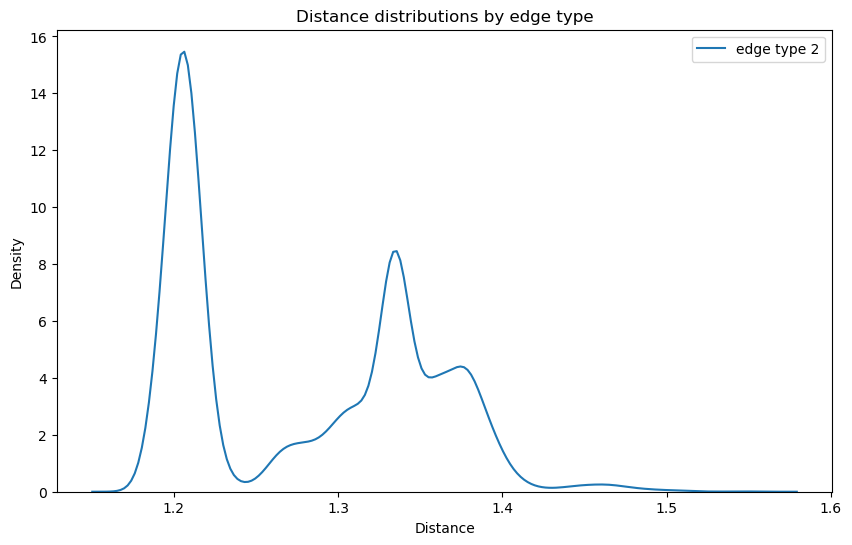

: 

In [ ]:
# plot kdes
import seaborn as sns
plt.figure(figsize=(10,6))
show_types = [ds_train.mol_to_torch_converter.bond_encoder['DOUBLE']+1]
for et in show_types:
    sns.kdeplot(all_dists[all_types==et], label=f'edge type {et}', bw_adjust=1.)
plt.xlabel('Distance')
plt.ylabel('Density')
plt.title('Distance distributions by edge type')
plt.legend()
plt.show()

In [25]:
from src.data.datasets.qm9 import QM9Raw, QM9Smiles, QM9

ds_raw = QM9Raw()
ds_smiles = QM9Smiles()
ds = QM9(
    split='train',
    include_pos=True,
    include_charges=True,
    sanitize=False,
    remove_hydrogens=True,
    kekulize=True,
    hard_remove_hydrogens=False
)


In [26]:
for i, g in enumerate(ds):
    if ds.x.shape[0] != ds.node_pos.shape[0]:
        print('mismatch at index', i)

In [11]:
None in ds_smiles

False

In [5]:
print(len(ds_raw), len(ds_smiles), len(ds))

130831 130831 130831


In [6]:
from src.data.simple_transforms.molecular import mol2smiles

In [7]:
ds.mol_to_torch_converter.include_pos

True

In [8]:
display(ds_raw[i][0])
ds.mol_to_torch_converter.graph_to_molecule(
    ds.mol_to_torch_converter.molecule_to_graph(
        ds_raw[i][0],
        
    )
)

NameError: name 'i' is not defined

smiles:		 CCC(C)O
from mol:	 CC[C@@H](C)O
from torch:	 CCC(C)O


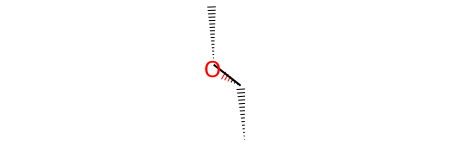

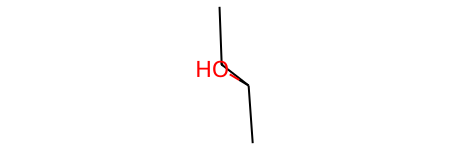

In [10]:
from rdkit import Chem
i = 80
mol = ds.mol_to_torch_converter.graph_to_molecule(ds[i])
print('smiles:\t\t', ds_smiles[i])
print('from mol:\t', mol2smiles(ds_raw[i][0], sanitize=False, isomeric=True))
# sanitize mol
Chem.SanitizeMol(mol)
mol = Chem.AddHs(mol)
Chem.SanitizeMol(mol)
Chem.AssignStereochemistry(mol, force=True, cleanIt=True)
mol = Chem.RemoveHs(mol)
print('from torch:\t', mol2smiles(mol, sanitize=False, isomeric=True))
display(ds_raw[i][0])
display(mol)

In [11]:
# get bonds in molecule from ds_raw
[ (atom1.GetSymbol(), atom2.GetSymbol(), bond.GetBondType()) for bond in ds_raw[i][0].GetBonds() for atom1 in [bond.GetBeginAtom()] for atom2 in [bond.GetEndAtom()] ]

[('C', 'O', rdkit.Chem.rdchem.BondType.SINGLE),
 ('C', 'C', rdkit.Chem.rdchem.BondType.SINGLE),
 ('C', 'C', rdkit.Chem.rdchem.BondType.SINGLE),
 ('C', 'C', rdkit.Chem.rdchem.BondType.SINGLE)]

In [12]:
[atom.GetSymbol() for atom in ds_raw[i][0].GetAtoms()]

['C', 'C', 'C', 'C', 'O']

In [ ]:
for sm, mol in zip(ds_smiles, ds):
    sm2 = mol2smiles(mol, sanitize=False, isomeric=False)
    if sm != sm2:
        print('mismatch')
        print(sm)
        print(sm2)

KeyError: 0

In [25]:
from rdkit import Chem

sm = "CCC(C)O"
mol = Chem.MolFromSmiles(sm)

print("MolToSmiles (isomeric):", Chem.MolToSmiles(mol, isomericSmiles=True))
print("Num atoms:", mol.GetNumAtoms())
for a in mol.GetAtoms():
    print(a.GetIdx(), a.GetSymbol(), "chiralTag=", a.GetChiralTag(), "charge=", a.GetFormalCharge(),
          "deg=", a.GetDegree(), "totalHs=", a.GetTotalNumHs())

print("chiral centers:", Chem.FindMolChiralCenters(mol, includeUnassigned=True))

MolToSmiles (isomeric): CCC(C)O
Num atoms: 5
0 C chiralTag= CHI_UNSPECIFIED charge= 0 deg= 1 totalHs= 3
1 C chiralTag= CHI_UNSPECIFIED charge= 0 deg= 2 totalHs= 2
2 C chiralTag= CHI_UNSPECIFIED charge= 0 deg= 3 totalHs= 1
3 C chiralTag= CHI_UNSPECIFIED charge= 0 deg= 1 totalHs= 3
4 O chiralTag= CHI_UNSPECIFIED charge= 0 deg= 1 totalHs= 1
chiral centers: [(2, '?')]
